# Every log–log plot is a straight line, and I’m tired of pretending it isn’t.

---
Filipe Borges
f3l5p7@yahoo.com.br


This notebook compares the same dataset in linear and log–log coordinates. In the first experiment the model is $y=Cx^{\alpha}+\varepsilon$, where $\varepsilon\sim\mathcal{N}(0,\sigma_\varepsilon)$ is purely random additive noise with fixed standard deviation. To keep the log–log panel valid, non-positive draws are re-sampled rather than clipped, avoiding an artificial floor in the data. The second experiment keeps the cubic model for comparison.\n

For strictly positive $y$, start from

$$y = f(x) + \varepsilon.$$

When $|\varepsilon|/f(x)$ is small, a first-order expansion gives

$$\log y = \log\!\big(f(x)+\varepsilon\big) \approx \log f(x) + \frac{\varepsilon}{f(x)}.$$

So additive noise is converted into a relative perturbation. The apparent spread in log space therefore shrinks where $f(x)$ is large, and the transformed noise variance follows

$$\mathrm{Var}(\varepsilon_{\log}) \approx \frac{\mathrm{Var}(\varepsilon)}{f(x)^2}.$$

This is why curvature can look suppressed and local elasticity can resemble an almost constant slope over finite ranges, even when the underlying model is not a true power law.


In [96]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    plt.style.use("../style/myStyle.mplstyle")
except OSError:
    plt.style.use("style/myStyle.mplstyle")


In [ ]:
rng = np.random.default_rng(42)
N = 400
x = np.logspace(0, 4, N)

# First experiment: y = C*x^alpha + eps
C = 1.0e6
alpha = 0.7
y_true = C * x**alpha

# Purely random additive Gaussian noise with fixed standard deviation
sigma = 0.3 * y_true.min()
if not np.all(y_true - 4 * sigma > 0):
    sigma = 0.24 * y_true.min()
assert np.all(y_true - 4 * sigma > 0)

eps = rng.normal(loc=0.0, scale=sigma, size=N)
y_noisy = y_true + eps
if np.any(y_noisy <= 0):
    raise ValueError("Non-positive y values found. Reduce sigma to keep log scaling valid.")

# Power-law L2 fit in linear space: y = A * x^k, minimizing ||y - A x^k||_2
k_grid = np.linspace(0.0, 2.0, 4001)
best_sse = np.inf
A_power_lin = np.nan
k_power_lin = np.nan
for k in k_grid:
    xk = x ** k
    A = np.dot(y_noisy, xk) / np.dot(xk, xk)
    y_hat = A * xk
    sse = np.sum((y_noisy - y_hat) ** 2)
    if sse < best_sse:
        best_sse = sse
        A_power_lin = A
        k_power_lin = k
y_fit_power_lin = A_power_lin * x ** k_power_lin
ss_tot_lin = np.sum((y_noisy - np.mean(y_noisy)) ** 2)
r2_power_lin = 1.0 - best_sse / ss_tot_lin

# Linear L2 fit in log-log space: log10(y) = m*log10(x) + b
coef_log_lin = np.polyfit(np.log10(x), np.log10(y_noisy), 1)
m_log_lin = coef_log_lin[0]
b_log_lin = coef_log_lin[1]
y_fit_log_linear = 10 ** b_log_lin * x ** m_log_lin
logy = np.log10(y_noisy)
logy_fit = m_log_lin * np.log10(x) + b_log_lin
ss_res_log = np.sum((logy - logy_fit) ** 2)
ss_tot_log = np.sum((logy - np.mean(logy)) ** 2)
r2_log_linear = 1.0 - ss_res_log / ss_tot_log

assert np.all(x > 0.0)
assert np.all(y_true > 0.0)
assert np.all(y_noisy > 0.0)


PosixPath('../assets/loglog_vs_linear.png')

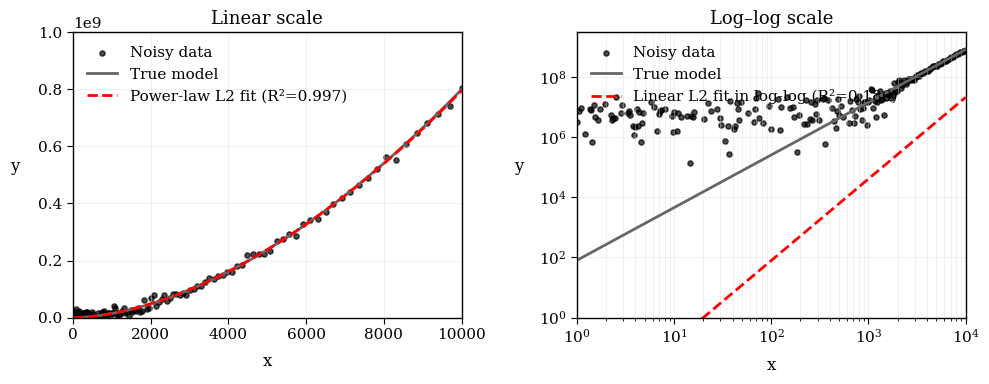

In [98]:
fig, axes = plt.subplots(1, 2)

# Left panel: linear axes with power-law L2 fit in linear space
axes[0].scatter(x, y_noisy, s=14, alpha=0.70, color="black", label="Noisy data")
axes[0].plot(x, y_true, color="0.4", label="True model")
axes[0].plot(x, y_fit_power_lin, linestyle="--", color="red", label=f"Power-law L2 fit (R²={r2_power_lin:.3f})")
axes[0].set_title("Linear scale")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y", rotation=0)
axes[0].yaxis.label.set_rotation(0)
axes[0].yaxis.set_label_coords(-0.15, 0.5)
axes[0].set_xlim(0, 10000)
axes[0].set_ylim(0, 2000000000)
axes[0].grid(True, which="both", color="0.85", linewidth=0.4, alpha=0.7)
for spine in axes[0].spines.values():
    spine.set_visible(True)
axes[0].legend(loc="upper left")

# Right panel: log-log axes with linear L2 fit in log-log space
axes[1].scatter(x, y_noisy, s=14, alpha=0.70, color="black", label="Noisy data")
axes[1].plot(x, y_true, color="0.4", label="True model")
axes[1].plot(x, y_fit_log_linear, linestyle="--", color="red", label=f"Linear L2 fit in log-log (R²={r2_log_linear:.3f})")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Log–log scale")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y", rotation=0)
axes[1].yaxis.label.set_rotation(0)
axes[1].yaxis.set_label_coords(-0.15, 0.5)
axes[1].set_xlim(1, 10000)
axes[1].set_ylim(100000, 3000000000)
axes[1].grid(True, which="both", color="0.85", linewidth=0.4, alpha=0.7)
for spine in axes[1].spines.values():
    spine.set_visible(True)
axes[1].legend(loc="upper left")

fig.tight_layout(w_pad=2.0)
output_path = Path("../assets/loglog_vs_linear.png")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
output_path


In [99]:
plt.show()


## Cubic model: same exercise with stronger curvature

Now we repeat the same comparison using a cubic deterministic trend, $f(x)=x^3+x+100$, with additive Gaussian noise. The construction remains strictly positive after clipping, so the log–log axis is always valid.


In [100]:
rng_cubic = np.random.default_rng(123)
N_cubic = 300
x_cubic = np.logspace(0, 4, N_cubic)
y_true_cubic = x_cubic**3 + x_cubic + 100.0
eps_cubic = rng_cubic.normal(loc=0.0, scale=0.16 * y_true_cubic)
y_noisy_cubic = np.clip(y_true_cubic + eps_cubic, 1e-8, None)

# Power-law L2 fit in linear space: y = A * x^k
k_grid_cubic = np.linspace(0.0, 5.0, 10001)
best_sse_cubic = np.inf
A_power_lin_cubic = np.nan
k_power_lin_cubic = np.nan
for k in k_grid_cubic:
    xk = x_cubic ** k
    A = np.dot(y_noisy_cubic, xk) / np.dot(xk, xk)
    y_hat = A * xk
    sse = np.sum((y_noisy_cubic - y_hat) ** 2)
    if sse < best_sse_cubic:
        best_sse_cubic = sse
        A_power_lin_cubic = A
        k_power_lin_cubic = k
y_fit_power_lin_cubic = A_power_lin_cubic * x_cubic ** k_power_lin_cubic
ss_tot_lin_cubic = np.sum((y_noisy_cubic - np.mean(y_noisy_cubic)) ** 2)
r2_power_lin_cubic = 1.0 - best_sse_cubic / ss_tot_lin_cubic

# Linear L2 fit in log-log space
coef_log_lin_cubic = np.polyfit(np.log10(x_cubic), np.log10(y_noisy_cubic), 1)
m_log_lin_cubic = coef_log_lin_cubic[0]
b_log_lin_cubic = coef_log_lin_cubic[1]
y_fit_log_linear_cubic = 10 ** b_log_lin_cubic * x_cubic ** m_log_lin_cubic
logy_cubic = np.log10(y_noisy_cubic)
logy_fit_cubic = m_log_lin_cubic * np.log10(x_cubic) + b_log_lin_cubic
ss_res_log_cubic = np.sum((logy_cubic - logy_fit_cubic) ** 2)
ss_tot_log_cubic = np.sum((logy_cubic - np.mean(logy_cubic)) ** 2)
r2_log_linear_cubic = 1.0 - ss_res_log_cubic / ss_tot_log_cubic

assert np.all(x_cubic > 0.0)
assert np.all(y_true_cubic > 0.0)
assert np.all(y_noisy_cubic > 0.0)


PosixPath('../assets/loglog_vs_linear_cubic.png')

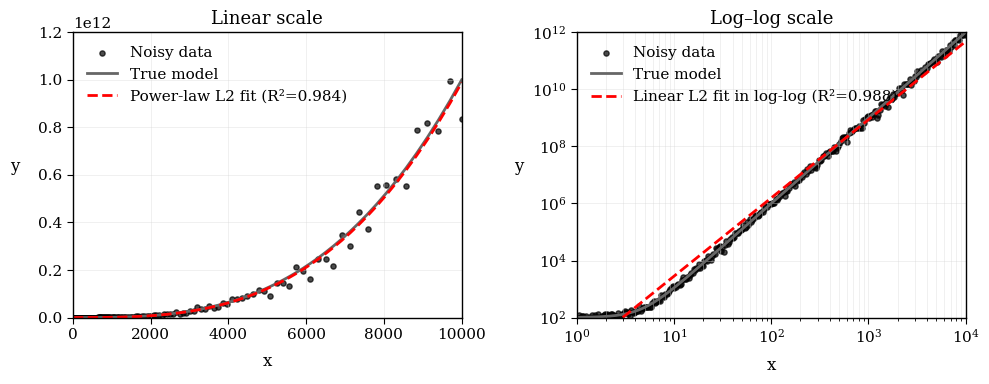

In [101]:
fig_cubic, axes_cubic = plt.subplots(1, 2)

axes_cubic[0].scatter(x_cubic, y_noisy_cubic, s=14, alpha=0.70, color="black", label="Noisy data")
axes_cubic[0].plot(x_cubic, y_true_cubic, color="0.4", label="True model")
axes_cubic[0].plot(x_cubic, y_fit_power_lin_cubic, linestyle="--", color="red", label=f"Power-law L2 fit (R²={r2_power_lin_cubic:.3f})")
axes_cubic[0].set_title("Linear scale")
axes_cubic[0].set_xlabel("x")
axes_cubic[0].set_ylabel("y", rotation=0)
axes_cubic[0].yaxis.label.set_rotation(0)
axes_cubic[0].yaxis.set_label_coords(-0.15, 0.5)
axes_cubic[0].set_xlim(0, 10000)
axes_cubic[0].set_ylim(0, 1200000000000)
axes_cubic[0].grid(True, which="both", color="0.85", linewidth=0.4, alpha=0.7)
for spine in axes_cubic[0].spines.values():
    spine.set_visible(True)
axes_cubic[0].legend(loc="upper left")

axes_cubic[1].scatter(x_cubic, y_noisy_cubic, s=14, alpha=0.70, color="black", label="Noisy data")
axes_cubic[1].plot(x_cubic, y_true_cubic, color="0.4", label="True model")
axes_cubic[1].plot(x_cubic, y_fit_log_linear_cubic, linestyle="--", color="red", label=f"Linear L2 fit in log-log (R²={r2_log_linear_cubic:.3f})")
axes_cubic[1].set_xscale("log")
axes_cubic[1].set_yscale("log")
axes_cubic[1].set_title("Log–log scale")
axes_cubic[1].set_xlabel("x")
axes_cubic[1].set_ylabel("y", rotation=0)
axes_cubic[1].yaxis.label.set_rotation(0)
axes_cubic[1].yaxis.set_label_coords(-0.15, 0.5)
axes_cubic[1].set_xlim(1, 10000)
axes_cubic[1].set_ylim(100, 1000000000000)
axes_cubic[1].grid(True, which="both", color="0.85", linewidth=0.4, alpha=0.7)
for spine in axes_cubic[1].spines.values():
    spine.set_visible(True)
axes_cubic[1].legend(loc="upper left")

fig_cubic.tight_layout(w_pad=2.0)
output_path_cubic = Path("../assets/loglog_vs_linear_cubic.png")
output_path_cubic.parent.mkdir(parents=True, exist_ok=True)
fig_cubic.savefig(output_path_cubic, dpi=300, bbox_inches="tight", facecolor="white")
output_path_cubic


In [102]:
plt.show()
